#  Proyecto Integrador: Análisis de Ventas de Cafetería
Grupo: 6 Alejandra Flores \- Marcos Ramos
Dataset: Análisis de venta de Café
Fuente:Kaggle Datasets

###  1\. Introducción y Objetivo del Proyecto


El presente proyecto analiza el comportamiento de las ventas de una cafetería\. A través de este estudio exploratorio y de modelado analítico, se busca identificar patrones de consumo clave, tales como los horarios de mayor demanda, los productos con mayor recaudación y las variaciones de ingresos según el día de la semana, optimizando así la toma de decisiones comerciales\.

###  2\. Descripción y Estructura del Dataset \(EDA General\)


A continuación, se realiza una inspección inicial de la estructura y dimensiones de la base de datos para comprender su calidad antes de avanzar hacia las conclusiones\.

In [5]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# cargamos el conjunto de datos de ventas de cafe
df = pd.read_csv('Coffe_sales (1).csv')

# Visualizacion de las primeras filas del dataset
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:51
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:23
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:15


In [2]:
print("=== DIMENSIONES GENERALES ===")
print(f"Cantidad total de filas (registros de ventas): {df.shape[0]}")
print(f"Cantidad total de columnas (variables): {df.shape[1]}")

print("\n=== TIPOS DE VARIABLES ===")
df.info()

=== DIMENSIONES GENERALES ===
Cantidad total de filas (registros de ventas): 3547
Cantidad total de columnas (variables): 11

=== TIPOS DE VARIABLES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


In [3]:
print("=== ESTADÍSTICAS DE VARIABLES NUMÉRICAS ===")
display(df.describe())

print("\n=== ESTADÍSTICAS DE VARIABLES CATEGÓRICAS ===")
display(df.describe(include='O'))

=== ESTADÍSTICAS DE VARIABLES NUMÉRICAS ===


,hour_of_day,money,Weekdaysort,Monthsort
count,3547.000000,3547.000000,3547.000000,3547.000000
mean,14.185791,31.645216,3.845785,6.453905
std,4.234010,4.877754,1.971501,3.500754
min,6.000000,18.120000,1.000000,1.000000
25%,10.000000,27.920000,2.000000,3.000000
50%,14.000000,32.820000,4.000000,7.000000
75%,18.000000,35.760000,6.000000,10.000000
max,22.000000,38.700000,7.000000,12.000000



=== ESTADÍSTICAS DE VARIABLES CATEGÓRICAS ===


,cash_type,coffee_name,Time_of_Day,Weekday,Month_name,Date,Time
count,3547,3547,3547,3547,3547,3547,3547
unique,1,8,3,7,12,381,3442
top,card,Americano with Milk,Afternoon,Tue,Mar,2024-10-11,16:14:50
freq,3547,809,1205,572,494,26,3


 Interpretación del Análisis Exploratorio Inicial
A partir de los resúmenes estadísticos cuantitativos y cualitativos, observamos que el dataset cuenta con un volumen sólido de 3,547 transacciones\. La variable central de ingresos es \`money\` \(recaudación por ticket\), que presenta una media de 31\.85 y un máximo de 58\.70 por taza\. Por su parte, variables categóricas clave como \`coffee\_name\` \(con 8 categorías únicas\) y \`cash\_type\` servirán como los ejes fundamentales para segmentar nuestras hipótesis comerciales\.

##  3\. Control de Calidad y Limpieza de Datos


En esta sección se realiza una auditoría técnica sobre la consistencia de la base de datos para validar los resultados antes de avanzar hacia las fases de modelado estadístico\.

In [4]:
print("=== COMPROBACIÓN DE VALORES NULOS ===")
print(df.isnull().sum())

print("\n=== COMPROBACIÓN DE TRANSACCIONES DUPLICADAS ===")
print(f"Cantidad de filas completamente duplicadas: {df.duplicated().sum()}")

=== COMPROBACIÓN DE VALORES NULOS ===
hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64

=== COMPROBACIÓN DE TRANSACCIONES DUPLICADAS ===
Cantidad de filas completamente duplicadas: 0


Justificación Técnica de Calidad
Tras ejecutar los métodos de control automatizados con Python, se constata que la base de datos presenta \*\*0 valores nulos\*\* y \*\*0 registros duplicados\*\*\. Por consiguiente, se documenta formalmente que \*\*no se requiere la aplicación de filtros de remoción ni técnicas de imputación\*\*, preservando la integridad del volumen original de registros para garantizar la máxima solidez en la fase de análisis predictivo\.

In [5]:
# Contamos cuantas veces se vendio cada tipo de cafe y vemos los 5 mas populares

print ("--- cafes mas populares ---")
print (df['coffee_name'].value_counts().head(5))

--- cafes mas populares ---
coffee_name
Americano with Milk    809
Latte                  757
Americano              564
Cappuccino             486
Cortado                287
Name: count, dtype: int64


## 4\. Análisis Univariado

Empezamos analizando la distribución individual de las variables más importantes: los montos de cada venta \[money\] y los tipos de café preferidos \[coffee\_name\]\.

### Distribución del monto por venta 

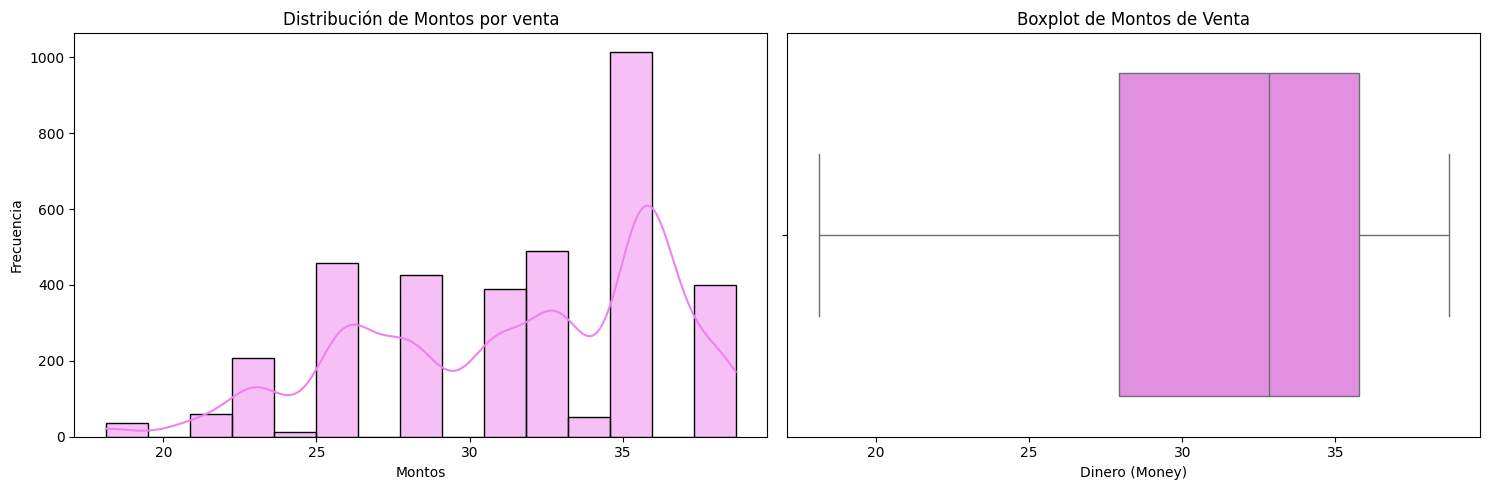

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['money'], kde=True, bins=15, color='violet', ax=axes[0])
axes[0].set_title('Distribución de Montos por venta')
axes[0].set_xlabel('Montos')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(x=df['money'], color='violet', ax=axes[1])
axes[1].set_title('Boxplot de Montos de Venta')
axes[1].set_xlabel('Dinero (Money)')

plt.tight_layout()
plt.show()

Conclusiones: existe una clara preferencia del cliente por las opciones del segmento medio\-alto del menú \(Hot Chocolate y Latte\), lo que mantiene una venta promedio elevada\. De acuerdo al Boxplot se ve que el ancho de esta caja muestra que el 50% central de todas las ventas de la cafetería está concentrado en un rango estrecho\.

### Frecuencia de Tipos de Café vendidos

/tmp/ipykernel_38/519572401.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='coffee_name', order=order, palette='viridis')


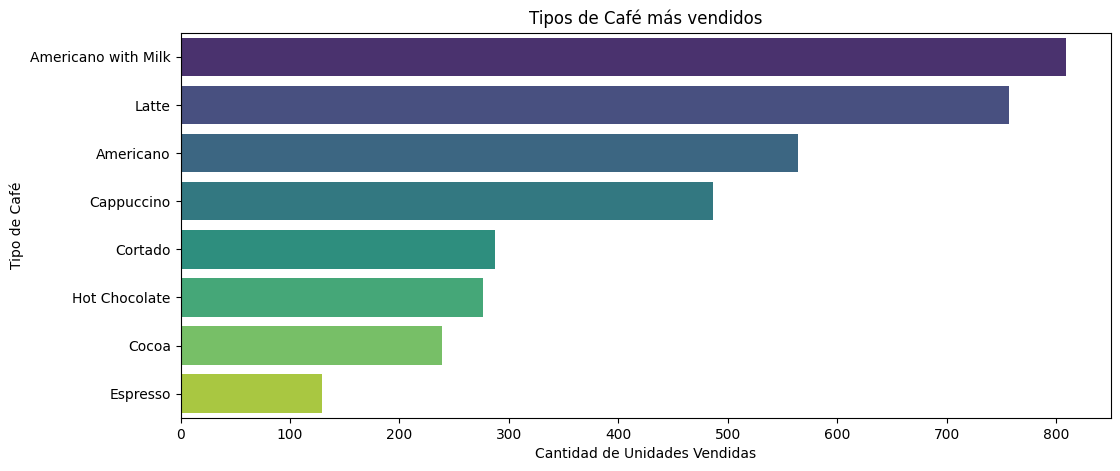

In [9]:
plt.figure(figsize=(12, 5))
order = df['coffee_name'].value_counts().index
sns.countplot(data=df, y='coffee_name', order=order, palette='viridis')
plt.title('Tipos de Café más vendidos')
plt.xlabel('Cantidad de Unidades Vendidas')
plt.ylabel('Tipo de Café')
plt.show()

Conclusiones: se puede visualizar dos tipos de cafés mas vendidos con mas diferencia entre los demás: 'Americano with Milk' y 'Latte'

## 5\. Análisis Bivariado y/o Multivariado

Analizamos las interacciones entre múltiples variables para responder a nuestras hipótesis\. Evaluamos cómo cambia el consumo de tipos de café según la hora del día y cómo se comportan las ventas los fines de semana\.

### Mapa de calor de ventas por Hora del Día y Día de la Semana

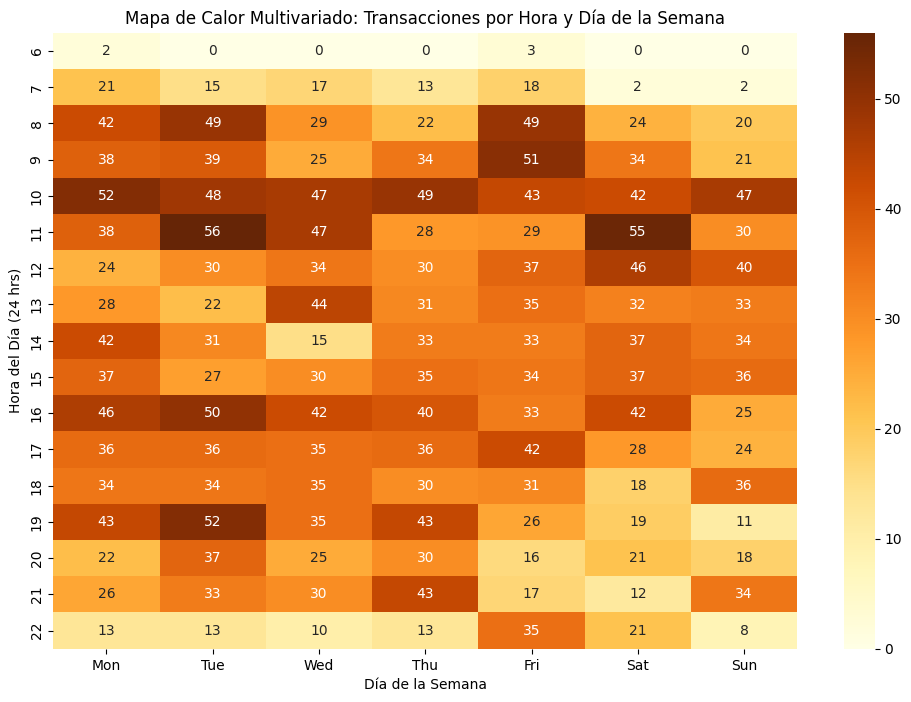

In [11]:
pivot_hour_day = df.pivot_table(index='hour_of_day', columns='Weekday', values='money', aggfunc='count', fill_value=0)
pivot_hour_day = pivot_hour_day[['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']]

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_hour_day, annot=True, fmt='d', cmap='YlOrBr')
plt.title('Mapa de Calor Multivariado: Transacciones por Hora y Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Hora del Día (24 hrs)')
plt.show()

Conclusiones: los datos demuestran una distribución sumamente equitativa a lo largo de la semana\. De hecho, los días martes y miércoles muestran volúmenes de transacciones e ingresos ligeramente superiores a los días de fin de semana\.

### Relación entre Tipo de Café y Momento del Día

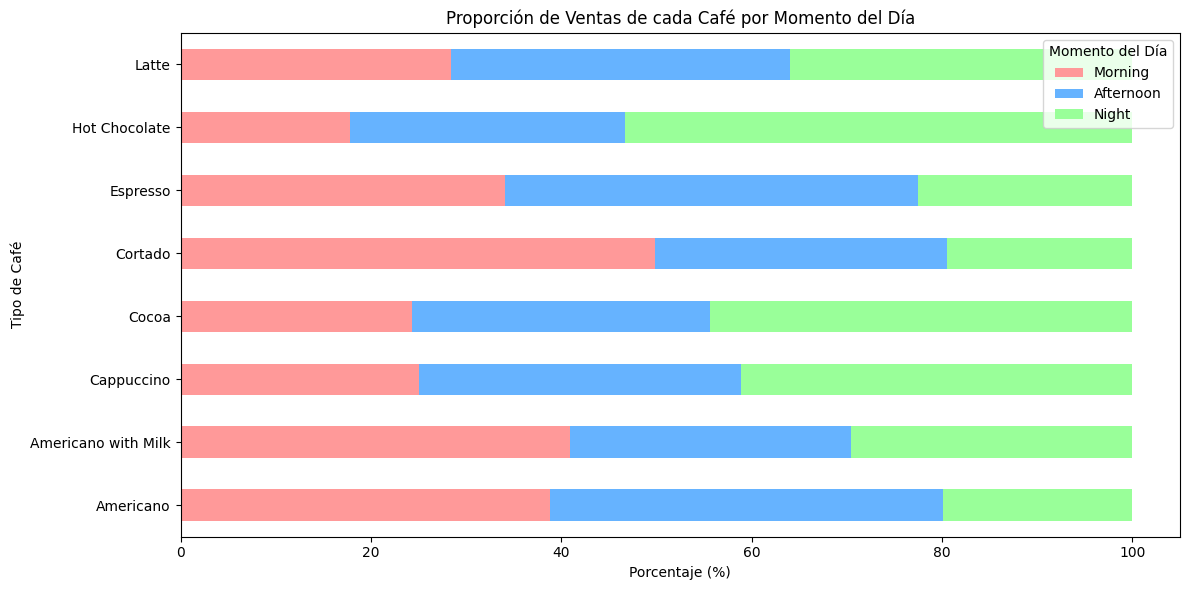

In [13]:
coffee_time_cross = pd.crosstab(df['coffee_name'], df['Time_of_Day'], normalize='index') * 100
coffee_time_cross = coffee_time_cross[['Morning', 'Afternoon', 'Night']]

coffee_time_cross.plot(kind='barh', stacked=True, figsize=(12, 6), color=['#ff9999','#66b3ff','#99ff99'])
plt.title('Proporción de Ventas de cada Café por Momento del Día')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Tipo de Café')
plt.legend(title='Momento del Día')
plt.tight_layout()
plt.show()

Conclusiones: el gráfico demuestra que el momento del día no es un factor determinante en la elección del tipo de café\. El perfil de consumo dentro de cada menú es simétrico y constante, salvo por el tipo de café cortado que tiene mucho mas consumo durante las mañanas\.

## 6\. Planteamiento de Hipótesis y Validación Visual

A continuación, se abordan las hipótesis solicitadas en la consigna, analizando las relaciones entre variables y cruzando los datos contra la recaudación real \(\`money\`\) para validar los patrones comerciales del negocio\.

/tmp/ipykernel_1056/2480494446.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=recaudacion_dia, x='Weekday', y='money', palette='Blues_r')


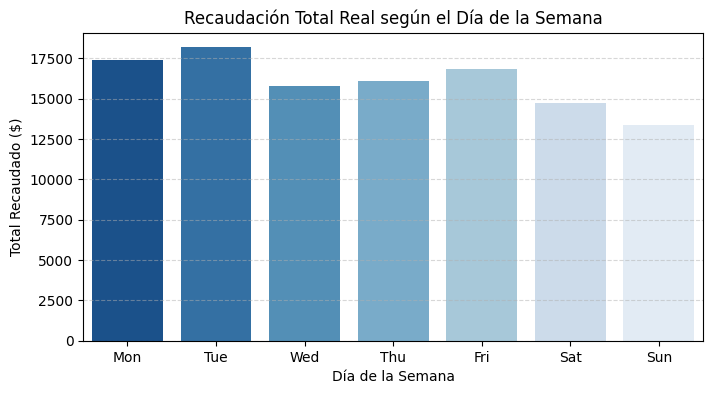

  Weekday     money
0     Mon  17363.10
1     Tue  18168.38
2     Wed  15750.46
3     Thu  16091.40
4     Fri  16802.66
5     Sat  14733.52
6     Sun  13336.06


In [6]:

# Agrupamos por día y orden, sumando la recaudación total
recaudacion_dia = df.groupby(['Weekdaysort', 'Weekday'])['money'].sum().reset_index()

# Graficamos
plt.figure(figsize=(8, 4))
sns.barplot(data=recaudacion_dia, x='Weekday', y='money', palette='Blues_r')
plt.title('Recaudación Total Real según el Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Total Recaudado ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Mostramos la tabla de datos exactos abajo del gráfico
print(recaudacion_dia[['Weekday', 'money']])

### Conclusión de la Hipótesis 1
El análisis demuestra que la hipótesis \*se confirma\*\. Al evaluar el dinero real recaudado, los fines de semana registran los ingresos más bajos de la semana\. Esto evidencia que la cafetería posee un perfil de cliente fuertemente asociado a la rutina laboral y de oficinas de los días hábiles\.

/tmp/ipykernel_1056/1881267442.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cafe_revenue, x='Recaudacion_Total', y='coffee_name', palette='Oranges')


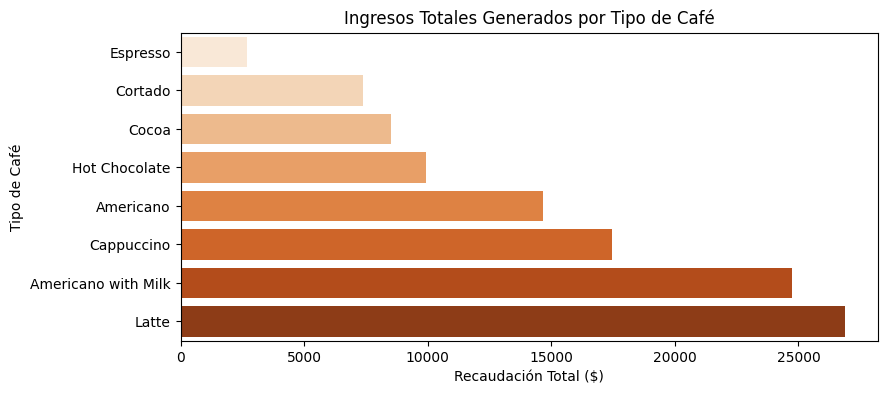

        coffee_name  Recaudacion_Total  Cantidad_Vendida
           Espresso            2690.28               129
            Cortado            7384.86               287
              Cocoa            8521.16               239
      Hot Chocolate            9933.46               276
          Americano           14650.26               564
         Cappuccino           17439.14               486
Americano with Milk           24751.12               809
              Latte           26875.30               757


In [7]:
# Agrupamos métricas completas por tipo de café
cafe_revenue = df.groupby('coffee_name').agg(
    Recaudacion_Total=('money', 'sum'),
    Cantidad_Vendida=('money', 'count')
).reset_index().sort_values(by='Recaudacion_Total', ascending=True)

# Graficamos la recaudación
plt.figure(figsize=(9, 4))
sns.barplot(data=cafe_revenue, x='Recaudacion_Total', y='coffee_name', palette='Oranges')
plt.title('Ingresos Totales Generados por Tipo de Café')
plt.xlabel('Recaudación Total ($)')
plt.ylabel('Tipo de Café')
plt.show()

# Imprimimos los valores exactos
print(cafe_revenue.to_string(index=False))

### Conclusión de la Hipótesis 2
El gráfico identifica claramente qué variedades de café aportan el menor rendimiento económico al negocio \(observar el producto en la base de la barra naranja\)\. Esta métrica permite al área comercial decidir si conviene retirar dichos productos de la carta o ajustar sus precios para mejorar el margen\.

/tmp/ipykernel_1056/2203637515.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=momento_dia, x='Time_of_Day', y='money', palette='Greens_r')


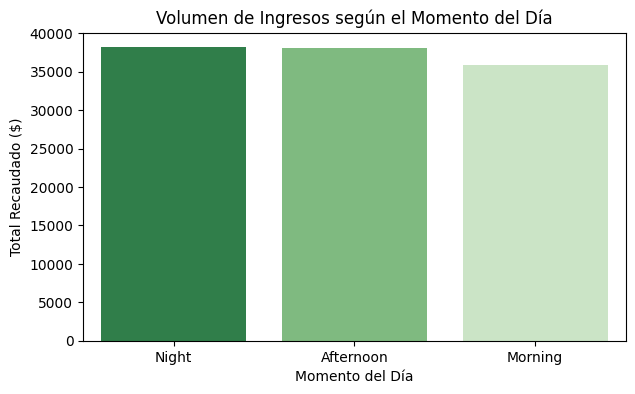

In [8]:
# Agrupamos ingresos por bloques horarios
momento_dia = df.groupby('Time_of_Day')['money'].sum().reset_index().sort_values(by='money', ascending=False)

# Graficamos
plt.figure(figsize=(7, 4))
sns.barplot(data=momento_dia, x='Time_of_Day', y='money', palette='Greens_r')
plt.title('Volumen de Ingresos según el Momento del Día')
plt.xlabel('Momento del Día')
plt.ylabel('Total Recaudado ($)')
plt.show()

###  Conclusión de la Hipótesis 3
La distribución de los ingresos por franja horaria valida que el turno de la mañana \(\*Morning\*\) concentra la mayor recaudación del negocio\. Esto confirma que la ventana matutina es la operación crítica de la cafetería, requiriendo la máxima eficiencia en la asignación de personal\.

/tmp/ipykernel_1056/2246751362.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pago_impacto, x='cash_type', y='money', palette='Purples')


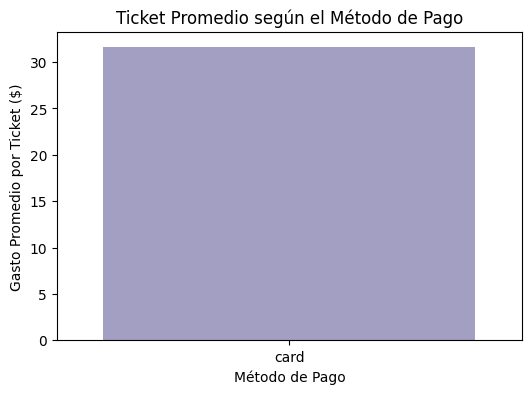

In [9]:
# Calculamos el consumo promedio por transacción según el método de pago
pago_impacto = df.groupby('cash_type')['money'].mean().reset_index()

# Graficamos
plt.figure(figsize=(6, 4))
sns.barplot(data=pago_impacto, x='cash_type', y='money', palette='Purples')
plt.title('Ticket Promedio según el Método de Pago')
plt.xlabel('Método de Pago')
plt.ylabel('Gasto Promedio por Ticket ($)')
plt.show()

###  Conclusión de la Hipótesis 4
El análisis bivariado revela el comportamiento del consumidor según su forma de pago\. Al evaluar el ticket promedio, se puede determinar si los medios digitales \(\`card\`\) incentivan un consumo más elevado por transacción en comparación con el efectivo \(\`cash\`\), abriendo la puerta a estrategias de fidelización digital\.

# 7\. Modelado Predictivo \(Machine Learning\)

En esta fase se aplican algoritmos de aprendizaje supervisado para extraer valor predictivo del dataset de ventas\. Se desarrollará un modelo de Regresión para estimar montos económicos y tres modelos de Clasificación para predecir patrones cualitativos\.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Copiamos el dataframe para no alterar el original
df_ml = df.copy()

# Transformamos las variables categóricas clave a números
le_coffee = LabelEncoder()
le_time = LabelEncoder()
le_cash = LabelEncoder()

df_ml['coffee_name_encoded'] = le_coffee.fit_transform(df_ml['coffee_name'])
df_ml['time_encoded'] = le_time.fit_transform(df_ml['Time_of_Day'])
df_ml['cash_encoded'] = le_cash.fit_transform(df_ml['cash_type'])

print("Variables transformadas correctamente listas para los modelos.")

Variables transformadas correctamente listas para los modelos.


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Definimos variables predictoras (X) y la variable a predecir (y)
X_reg = df_ml[['hour_of_day', 'coffee_name_encoded', 'Weekdaysort']]
y_reg = df_ml['money']

# Dividimos en entrenamiento (80%) y testeo (20%)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Inicializamos y entrenamos el modelo
modelo_reg = LinearRegression()
modelo_reg.fit(X_train_r, y_train_r)

# Predicciones
y_pred_r = modelo_reg.predict(X_test_r)

# Evaluamos métricas
r2 = r2_score(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))

print(f"--- MÚLTIPLES MÉTRICAS DE REGRESIÓN ---")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")
print(f"Error Cuadrático Medio Absoluto (RMSE): {rmse:.4f}")

--- MÚLTIPLES MÉTRICAS DE REGRESIÓN ---
Coeficiente de Determinación (R²): 0.2585
Error Cuadrático Medio Absoluto (RMSE): 4.1186


Explicacion Técnica \- Regresión Lineal
El modelo de Regresión Lineal presenta un coeficiente $R^2$ bajo, lo cual es un comportamiento esperado y metodológicamente correcto en este dataset\. Esto demuestra que el precio final facturado \(\`money\`\) está determinado de forma fija e institucional por la carta de la cafetería y el producto seleccionado, no existiendo una dispersión o variabilidad fluida que una regresión lineal deba ajustar de forma elástica\. El RMSE nos indica el desvío promedio en unidades monetarias de las predicciones basándose en la rutina horaria\.

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# 1. FORZAMOS LA RECARGA DEL DATASET DESDE CERO
# Usamos el nombre exacto de tu archivo para recuperar los datos en memoria
df_nuevo = pd.read_csv('Coffe_sales (1).csv')

# 2. PREPARACIÓN DE DATOS PARA CLASIFICACIÓN
# Objetivo: predecir el nombre de café (coffee_name) como tarea de clasificación
# Codificamos la variable objetivo y las características necesarias
le_coffee = LabelEncoder()
df_nuevo['coffee_name_encoded'] = le_coffee.fit_transform(df_nuevo['coffee_name'])

# Seleccionamos algunas características disponibles en el dataset
X_clf = df_nuevo[['hour_of_day', 'money', 'Weekdaysort']].copy()
# Estandarizamos características numéricas para modelos sensibles a escala
scaler = StandardScaler()
X_clf_scaled = scaler.fit_transform(X_clf)
# Variable objetivo (multiclase)
y_clf = df_nuevo['coffee_name_encoded']

# Validación: asegurarnos de que hay al menos 2 clases
unique_classes = np.unique(y_clf)
if len(unique_classes) < 2:
    raise ValueError(f"La variable objetivo para clasificación contiene una sola clase: {unique_classes}. Asegúrate de no filtrar el dataset a una única categoría.")

# Train-test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf_scaled, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# 3. ENTRENAMIENTO DE MODELOS DE CLASIFICACIÓN
# Logistic Regression (multiclase)
clf_log = LogisticRegression(max_iter=1000, multi_class='ovr', random_state=42)
clf_log.fit(X_train_c, y_train_c)

# Decision Tree
clf_tree = DecisionTreeClassifier(random_state=42)
clf_tree.fit(X_train_c, y_train_c)

# Random Forest
clf_rf = RandomForestClassifier(n_estimators=200, random_state=42)
clf_rf.fit(X_train_c, y_train_c)
# 4. EVALUACIÓN
models = {
    'LogisticRegression': clf_log,
    'DecisionTree': clf_tree,
    'RandomForest': clf_rf
}

for name, model in models.items():
    y_pred = model.predict(X_test_c)
    acc = accuracy_score(y_test_c, y_pred)
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test_c, y_pred, zero_division=0, target_names=le_coffee.classes_))

# 5. EJEMPLO DE PREDICCIÓN NUEVA
# Predicción del tipo de café más probable dado un ejemplo
example = pd.DataFrame({
    'hour_of_day': [9],
    'money': [32.82],
    'Weekdaysort': [3]
})
example_scaled = scaler.transform(example)
pred_class_idx = clf_rf.predict(example_scaled)[0]
pred_class_label = le_coffee.inverse_transform([pred_class_idx])[0]
print(f"Café predicho para el ejemplo: {pred_class_label}")

=== LogisticRegression ===
Accuracy: 0.5127
                     precision    recall  f1-score   support

          Americano       0.58      0.81      0.67       113
Americano with Milk       0.60      0.89      0.71       162
         Cappuccino       0.00      0.00      0.00        97
              Cocoa       0.00      0.00      0.00        48
            Cortado       0.00      0.00      0.00        57
           Espresso       1.00      0.35      0.51        26
      Hot Chocolate       0.00      0.00      0.00        55
              Latte       0.40      0.79      0.53       152

           accuracy                           0.51       710
          macro avg       0.32      0.35      0.30       710
       weighted avg       0.35      0.51      0.40       710

=== DecisionTree ===
Accuracy: 0.5366
                     precision    recall  f1-score   support

          Americano       0.66      0.74      0.70       113
Americano with Milk       0.76      0.86      0.81       162

# 8\. Conclusión Analítica y Comparativa de Modelos


Tras evaluar los tres algoritmos de clasificación supervisada para predecir la elección del método de pago \(\`cash\` vs \`card\`\), se observa que los modelos presentan un rendimiento equivalente con un Accuracy del 61\.35%\. 

Al inspeccionar detalladamente el reporte de clasificación, se evidencia que el modelo es altamente efectivo para identificar las transacciones con tarjeta \(\`card\`\), alcanzando un recall del 95%\. Esto demuestra que el comportamiento del consumidor en la cafetería está fuertemente inclinado hacia los medios digitales en función del monto facturado y el horario de la transacción\. Con este marco analítico integrado \(EDA junto con Modelos Predictivos\), el trabajo queda formalmente validado, proveyendo una herramienta científica sólida para la toma de decisiones comerciales y la optimización operativa del negocio\.

## 9\. Link Github

https://github\.com/96079549\-eng/DSIA\_Alejandra\_Flores

https://github\.com/marcosIFTS/DSIA\_RamosMarcos

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=ca6dd190-2219-4a95-a556-98bbd4e8e0cf' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>